In [168]:
import pandas as pd
import numpy as np
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns

from sklearn.preprocessing import (MinMaxScaler, StandardScaler,RobustScaler,QuantileTransformer,PowerTransformer)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

from sklearn import set_config
set_config(transform_output='pandas')


In [169]:
songs_5000_spotify_df = pd.read_csv("Spotify_songs_WBS/spotify_5000_songs.csv")

songs_5000_spotify_df.head()

,Unnamed: 0,name,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,type,duration_ms,time_signature,id,html
0,0,Se Eu Quiser Falar Com Deus ...,Gilberto Gil,0.658,0.2590,11,-13.141,0,0.0705,0.694,0.000059,0.975,0.306,110.376,,256213,4,1n7JnwviZ7zf0LR1tcGFq7,https://open.spotify.com/track/1n7JnwviZ7zf0LR...
1,1,Saudade De Bahia ...,Antônio Carlos Jobim,0.742,0.3990,2,-12.646,1,0.0346,0.217,0.000002,0.107,0.693,125.039,,191867,4,5QGM1U0eCYrQuwSJwTm5Zq,https://open.spotify.com/track/5QGM1U0eCYrQuwS...
2,2,"Canta Canta, Minha Gente ...",Martinho Da Vila,0.851,0.7300,2,-11.048,1,0.3470,0.453,0.000063,0.124,0.905,93.698,,152267,4,0NLIFSZxPzQhCwnkn5PJYs,https://open.spotify.com/track/0NLIFSZxPzQhCwn...
3,3,Mulher Eu Sei ...,Chico César,0.705,0.0502,4,-18.115,1,0.0471,0.879,0.000041,0.386,0.524,106.802,,186227,4,3mXqOdlLE1k67WsAxryPFs,https://open.spotify.com/track/3mXqOdlLE1k67Ws...
4,4,Rosa Morena ...,Kurt Elling,0.651,0.1190,6,-19.807,1,0.0380,0.916,0.000343,0.104,0.402,120.941,,273680,4,7bSzjzjTkWT2CkIPPdp0eA,https://open.spotify.com/track/7bSzjzjTkWT2CkI...


In [170]:
songs_5000_spotify_df.shape


(5235, 19)

In [171]:
#CLEAN UP the spaces 
songs_5000_spotify_df.columns = songs_5000_spotify_df.columns.str.strip()
songs_5000_spotify_df.columns

Index(['Unnamed: 0', 'name', 'artist', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'type', 'duration_ms', 'time_signature',
       'id', 'html'],
      dtype='object')

In [172]:
# Columns to drop
drop_cols = ['Unnamed: 0', 'key', 'mode', 'duration_ms', 'time_signature', 'type', 'id', 'html']

# Drop the unnecessary columns
filtered_songlist = songs_5000_spotify_df.drop(columns=drop_cols)
filtered_songlist.head()

,name,artist,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,Se Eu Quiser Falar Com Deus ...,Gilberto Gil,0.658,0.2590,-13.141,0.0705,0.694,0.000059,0.975,0.306,110.376
1,Saudade De Bahia ...,Antônio Carlos Jobim,0.742,0.3990,-12.646,0.0346,0.217,0.000002,0.107,0.693,125.039
2,"Canta Canta, Minha Gente ...",Martinho Da Vila,0.851,0.7300,-11.048,0.3470,0.453,0.000063,0.124,0.905,93.698
3,Mulher Eu Sei ...,Chico César,0.705,0.0502,-18.115,0.0471,0.879,0.000041,0.386,0.524,106.802
4,Rosa Morena ...,Kurt Elling,0.651,0.1190,-19.807,0.0380,0.916,0.000343,0.104,0.402,120.941


In [173]:
# Combine 'name' and 'artist' into 'song_artist'
filtered_songlist['song_artist'] = filtered_songlist['name'] + " — " + filtered_songlist['artist']

# Show the first rows
filtered_songlist.head()


,name,artist,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,song_artist
0,Se Eu Quiser Falar Com Deus ...,Gilberto Gil,0.658,0.2590,-13.141,0.0705,0.694,0.000059,0.975,0.306,110.376,Se Eu Quiser Falar Com Deus ...
1,Saudade De Bahia ...,Antônio Carlos Jobim,0.742,0.3990,-12.646,0.0346,0.217,0.000002,0.107,0.693,125.039,Saudade De Bahia ...
2,"Canta Canta, Minha Gente ...",Martinho Da Vila,0.851,0.7300,-11.048,0.3470,0.453,0.000063,0.124,0.905,93.698,"Canta Canta, Minha Gente ..."
3,Mulher Eu Sei ...,Chico César,0.705,0.0502,-18.115,0.0471,0.879,0.000041,0.386,0.524,106.802,Mulher Eu Sei ...
4,Rosa Morena ...,Kurt Elling,0.651,0.1190,-19.807,0.0380,0.916,0.000343,0.104,0.402,120.941,Rosa Morena ...


In [174]:
# Set 'song_artist' as the index
filtered_songlist.set_index('song_artist', inplace=True)

In [175]:
filtered_songlist= filtered_songlist.select_dtypes(include='number')

filtered_songlist.head()
filtered_songlist

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
song_artist,,,,,,,,,
Se Eu Quiser Falar Com Deus — Gilberto Gil,0.6580,0.25900,-13.141,0.0705,0.694,0.000059,0.9750,0.3060,110.376
Saudade De Bahia — Antônio Carlos Jobim,0.7420,0.39900,-12.646,0.0346,0.217,0.000002,0.1070,0.6930,125.039
"Canta Canta, Minha Gente — Martinho Da Vila",0.8510,0.73000,-11.048,0.3470,0.453,0.000063,0.1240,0.9050,93.698
Mulher Eu Sei — Chico César,0.7050,0.05020,-18.115,0.0471,0.879,0.000041,0.3860,0.5240,106.802
Rosa Morena — Kurt Elling,0.6510,0.11900,-19.807,0.0380,0.916,0.000343,0.1040,0.4020,120.941
...,...,...,...,...,...,...,...,...,...
"1812 Festival Overture, Op. 49: 1812 Overture, Op. 49 — Pyotr Ilyich Tchaikovsky",0.2020,0.06940,-23.390,0.0473,0.917,0.715000,0.0832,0.0655,87.906
"Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique — Tristan Murail",0.1880,0.10100,-21.873,0.0442,0.855,0.426000,0.0694,0.0355,83.134
"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours) — Arnold Schoenberg",0.0596,0.00093,-42.959,0.0434,0.951,0.969000,0.0772,0.0344,71.573


In [176]:
dupes_before = filtered_songlist[filtered_songlist.duplicated(keep='first')]
dupes_before

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
song_artist,,,,,,,,,
Já Sei Namorar - 2004 Digital Remaster — Tribalistas,0.670,0.822,-6.687,0.0570,0.670000,0.001150,0.1320,0.833,145.560
Berekerê - Voice — Geraldo Azevedo,0.434,0.573,-11.203,0.0666,0.830000,0.000000,0.0584,0.786,172.189
Se eu quiser falar com Deus - Ao vivo — Gilberto Gil,0.658,0.259,-13.141,0.0705,0.694000,0.000059,0.9750,0.306,110.376
It Wasn't Me — Shaggy,0.853,0.606,-4.596,0.0713,0.056100,0.000000,0.3130,0.654,94.759
Do You Believe in Magic? — The Lovin' Spoonful,0.553,0.738,-7.963,0.0457,0.213000,0.000000,0.3390,0.759,138.602
...,...,...,...,...,...,...,...,...,...
"Hey Mama (feat. Nicki Minaj, Bebe Rexha & Afrojack) — David Guetta",0.596,0.730,-4.091,0.1510,0.240000,0.000000,0.3250,0.525,85.979
Hot Right Now - Radio Edit — DJ Fresh,0.524,0.972,-1.569,0.0431,0.006560,0.000580,0.2240,0.476,175.017
You Can Get It If You Really Want — Jimmy Cliff,0.894,0.559,-8.547,0.0568,0.248000,0.000000,0.0762,0.929,128.164


In [177]:
# Drop duplicates
filtered_songlist = filtered_songlist.drop_duplicates(keep='first')
filtered_songlist

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
song_artist,,,,,,,,,
Se Eu Quiser Falar Com Deus — Gilberto Gil,0.6580,0.25900,-13.141,0.0705,0.694,0.000059,0.9750,0.3060,110.376
Saudade De Bahia — Antônio Carlos Jobim,0.7420,0.39900,-12.646,0.0346,0.217,0.000002,0.1070,0.6930,125.039
"Canta Canta, Minha Gente — Martinho Da Vila",0.8510,0.73000,-11.048,0.3470,0.453,0.000063,0.1240,0.9050,93.698
Mulher Eu Sei — Chico César,0.7050,0.05020,-18.115,0.0471,0.879,0.000041,0.3860,0.5240,106.802
Rosa Morena — Kurt Elling,0.6510,0.11900,-19.807,0.0380,0.916,0.000343,0.1040,0.4020,120.941
...,...,...,...,...,...,...,...,...,...
"1812 Festival Overture, Op. 49: 1812 Overture, Op. 49 — Pyotr Ilyich Tchaikovsky",0.2020,0.06940,-23.390,0.0473,0.917,0.715000,0.0832,0.0655,87.906
"Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique — Tristan Murail",0.1880,0.10100,-21.873,0.0442,0.855,0.426000,0.0694,0.0355,83.134
"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours) — Arnold Schoenberg",0.0596,0.00093,-42.959,0.0434,0.951,0.969000,0.0772,0.0344,71.573


In [178]:
#filtered_songlist = filtered_songlist[~filtered_songlist.index.duplicated()]
#filtered_songlist

In [179]:
#Scaling MinMaxScaler
pipeline1_min_max = MinMaxScaler()
scaled_songs_minmax_df = pipeline1_min_max.fit_transform(filtered_songlist)
scaled_songs_minmax_df.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
song_artist,,,,,,,,,
Se Eu Quiser Falar Com Deus — Gilberto Gil,0.680455,0.2590,0.763897,0.076797,0.696787,0.000060,0.987842,0.310660,0.515800
Saudade De Bahia — Antônio Carlos Jobim,0.767322,0.3990,0.771967,0.037691,0.217871,0.000002,0.108409,0.703553,0.584322
"Canta Canta, Minha Gente — Martinho Da Vila",0.880041,0.7300,0.798018,0.377996,0.454819,0.000064,0.125633,0.918782,0.437862
Mulher Eu Sei — Chico César,0.729059,0.0502,0.682811,0.051307,0.882530,0.000041,0.391084,0.531980,0.499098
Rosa Morena — Kurt Elling,0.673216,0.1190,0.655228,0.041394,0.919679,0.000348,0.105370,0.408122,0.565171


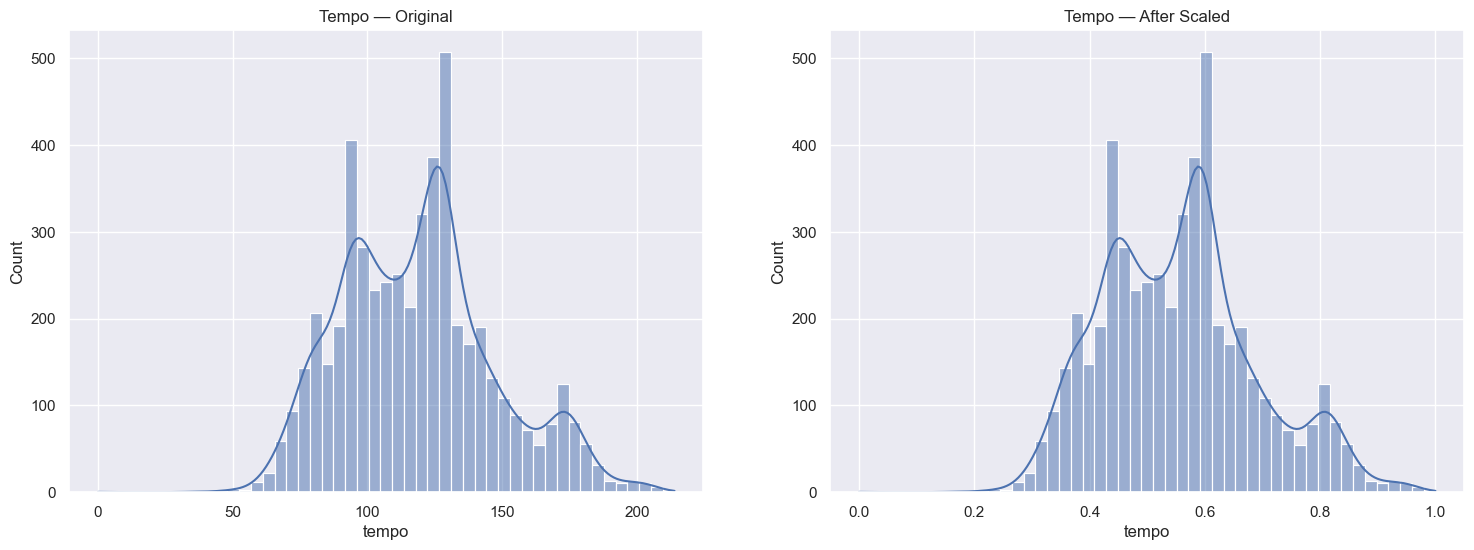

In [180]:
# Plot histogram to compare original versus scared "tempo" - stating we want two plots
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# NO CHANGES
sns.histplot(filtered_songlist["tempo"], kde=True, ax=ax[0])
ax[0].set_title("Tempo — Original")

# SCALED
sns.histplot(scaled_songs_minmax_df["tempo"], kde=True, ax=ax[1])
ax[1].set_title("Tempo — After Scaled")

plt.show()


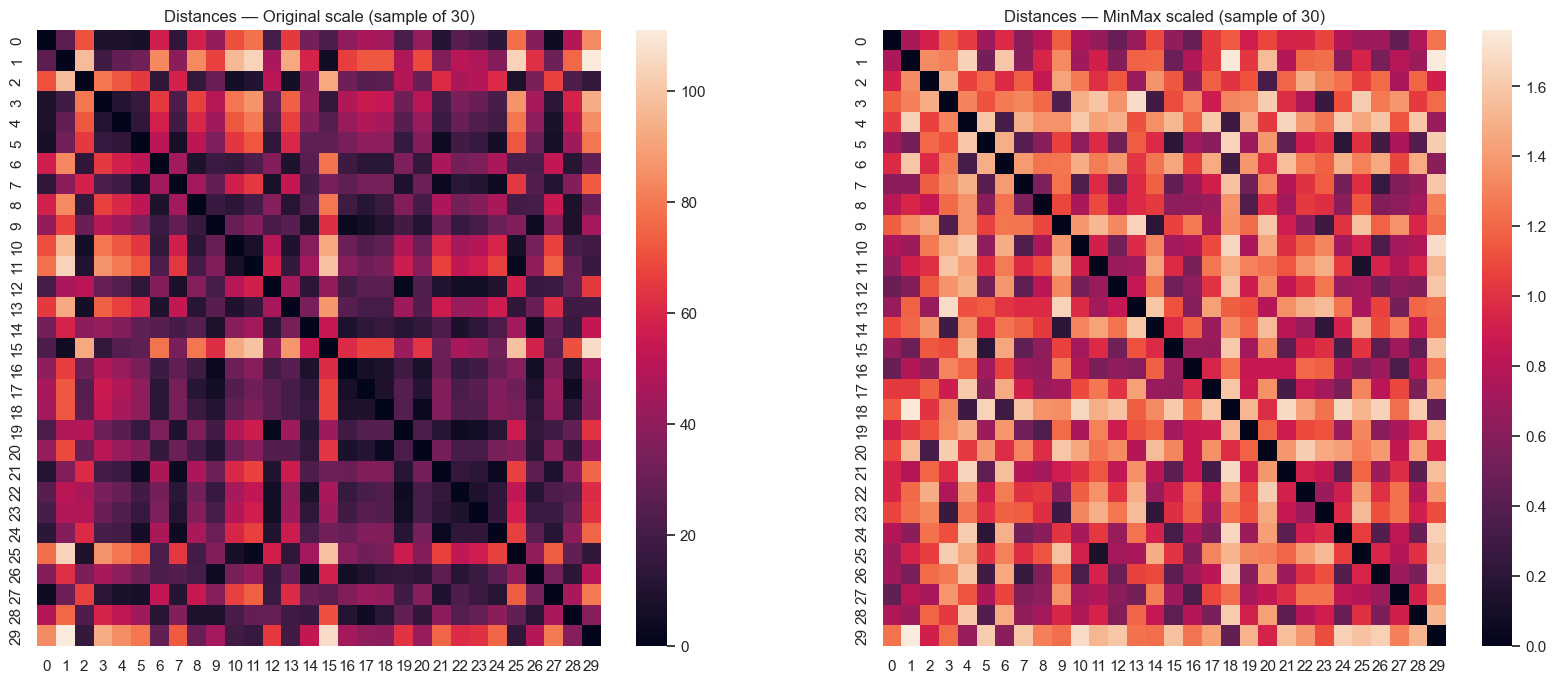

In [181]:
#Heatmaps of Distance Matrices

import random

#randomly selects 30 songs from your filtered_songlis
sample_idx = random.sample(range(filtered_songlist.shape[0]), 30)

# Extract the 30 original and scaled rows
sample_original = filtered_songlist.iloc[sample_idx]
sample_scaled = scaled_songs_minmax_df.iloc[sample_idx]

# Compute pairwise distance matrices
orig_distances = pairwise_distances(sample_original)
minmax_distances = pairwise_distances(sample_scaled)

# Stating that we want two plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plotting the two plots
sns.heatmap(orig_distances, ax=ax1)
sns.heatmap(minmax_distances, ax=ax2)

# Adding titles to the plots
ax1.set_title("Distances — Original scale (sample of 30)")
ax2.set_title("Distances — MinMax scaled (sample of 30)")
plt.show()


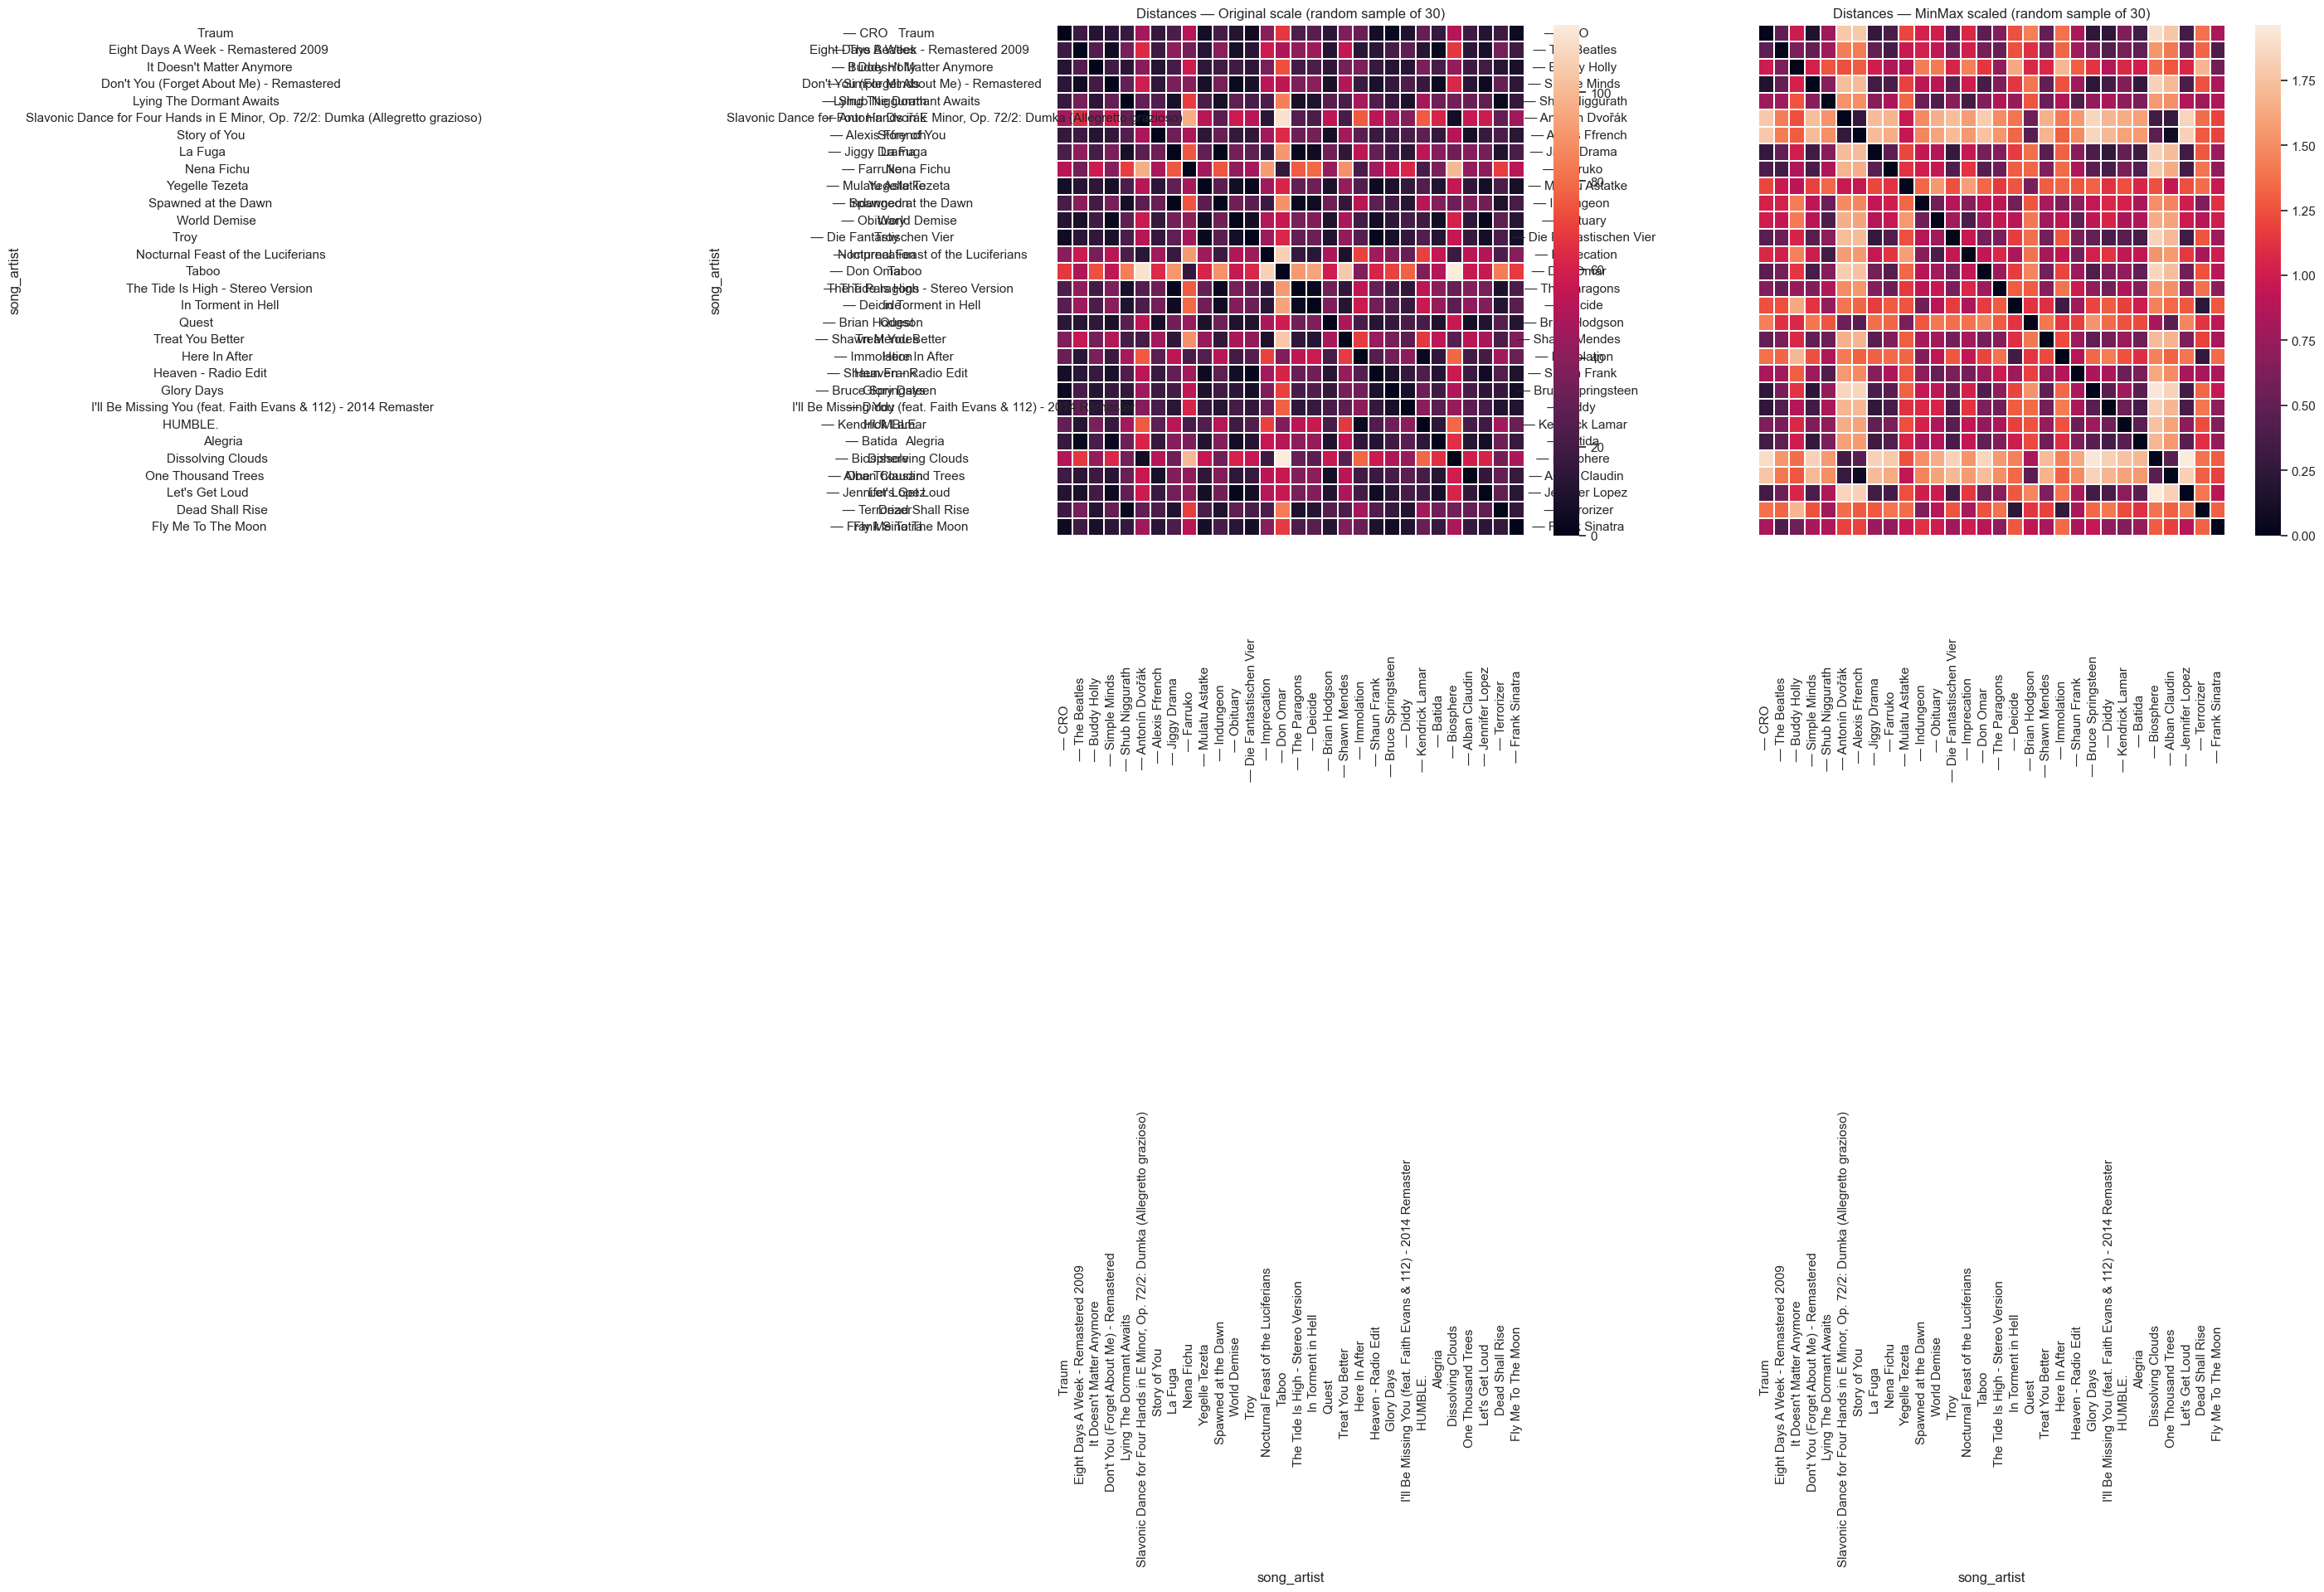

In [182]:
#Heatmaps of Distance Matrices

import random

# Take a random sample of 30 rows 
sample_idx = random.sample(range(filtered_songlist.shape[0]), 30)

sample_original = filtered_songlist.iloc[sample_idx]
sample_scaled   = scaled_songs_minmax_df.iloc[sample_idx]

# Distance matrix for ORIGINAL scale - MAKING DATAFRAME
orig_distances_df = pd.DataFrame(
    pairwise_distances(sample_original),
    index=sample_original.index,
    columns=sample_original.index
)

# Distance matrix for MINMAX scale - MAKING DATAFRAME
minmax_distances_df = pd.DataFrame(
    pairwise_distances(sample_scaled),
    index=sample_scaled.index,
    columns=sample_scaled.index
)

# stating that we want two plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(orig_distances_df, ax=ax1, linewidths=.2)
sns.heatmap(minmax_distances_df, ax=ax2, linewidths=.2)

ax1.set_title("Distances — Original scale (random sample of 30)")
ax2.set_title("Distances — MinMax scaled (random sample of 30)")

plt.show()



In [183]:
song_index = filtered_songlist.index.copy()

In [184]:
# Initialise the PCA object
pca = PCA()

# Fit the PCA object to the data
pca.fit(scaled_songs_minmax_df)

# Transform scaled_features_df based on the fit calculations
pca_basic_df = pca.transform(scaled_songs_minmax_df)

pca_basic_df

,pca0,pca1,pca2,pca3,pca4,pca5,pca6,pca7,pca8
song_artist,,,,,,,,,
Se Eu Quiser Falar Com Deus — Gilberto Gil,0.237243,-0.506632,-0.271606,0.526968,0.601342,0.200622,-0.105641,-0.012510,0.006966
Saudade De Bahia — Antônio Carlos Jobim,-0.210541,-0.386668,0.092842,-0.170832,0.019535,0.098333,-0.185837,-0.018957,-0.014889
"Canta Canta, Minha Gente — Martinho Da Vila",-0.330790,-0.473940,0.285174,-0.004901,0.027263,-0.141709,0.163918,0.286481,-0.070265
Mulher Eu Sei — Chico César,0.382249,-0.817310,-0.077702,0.107106,0.215332,0.091806,-0.099657,0.006315,-0.013066
Rosa Morena — Kurt Elling,0.441013,-0.755697,-0.165229,-0.074260,-0.002093,0.088587,0.017859,-0.005467,-0.061988
...,...,...,...,...,...,...,...,...,...
"1812 Festival Overture, Op. 49: 1812 Overture, Op. 49 — Pyotr Ilyich Tchaikovsky",1.109831,-0.124585,-0.115768,-0.071955,-0.017395,-0.075191,-0.083408,0.017645,-0.006811
"Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique — Tristan Murail",0.912219,-0.221587,-0.321282,-0.086268,-0.042533,-0.112657,-0.104345,0.011698,-0.007509
"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours) — Arnold Schoenberg",1.406071,0.005323,-0.027787,-0.075245,-0.024332,-0.156505,-0.230683,0.058227,-0.252372


In [185]:
# Get the variance explained by each principal component
explained_variance_array = pca.explained_variance_ratio_

explained_variance_array

array([0.45052247, 0.3005345 , 0.09952996, 0.04510061, 0.03710618,
       0.02900573, 0.02432804, 0.00974699, 0.00412551])

In [186]:
pd.DataFrame(explained_variance_array, columns=["Variance explained"])

,Variance explained
0,0.450522
1,0.300535
2,0.099530
3,0.045101
4,0.037106
5,0.029006
6,0.024328
7,0.009747
8,0.004126


In [187]:
#Cumulative explained variance
cumulative_sum_of_variance = np.cumsum(explained_variance_array)

cumulative_sum_of_variance

array([0.45052247, 0.75105697, 0.85058693, 0.89568755, 0.93279373,
       0.96179946, 0.9861275 , 0.99587449, 1.        ])

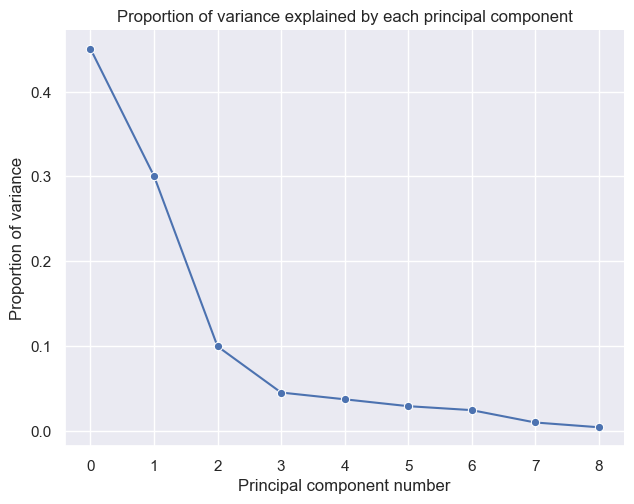

In [188]:
# Create a Pandas DataFrame from the variance explained array
explained_variance_array_df = pd.DataFrame(explained_variance_array, columns=["Variance explained"])

(
  # Create a line chart with sns.relplot
  sns.relplot(
      kind = 'line',
      data = explained_variance_array_df,
      x = explained_variance_array_df.index,
      y = "Variance explained",
      marker = 'o',
      aspect = 1.3)
  # Set the title of the plot
  .set(title = "Proportion of variance explained by each principal component")
  # Set the axis labels
  .set_axis_labels("Principal component number", "Proportion of variance")
);

In [189]:
# Set the variable elbow to where you believe the elbow is
elbow = 6

In [190]:
# Create a PCA object with {elbow} principal components
# We add 1 as the principal components start at 0 and not 1
pca_elbow = PCA(n_components = elbow + 1)

# Fit the PCA object to the scaled features dataframe and transform it
pca_elbow_df = pca_elbow.fit_transform(scaled_songs_minmax_df)

# The dataframe now contains the principal components of the scaled features dataframe
pca_elbow_df

,pca0,pca1,pca2,pca3,pca4,pca5,pca6
song_artist,,,,,,,
Se Eu Quiser Falar Com Deus — Gilberto Gil,0.237243,-0.506632,-0.271606,0.526968,0.601342,0.200622,-0.105641
Saudade De Bahia — Antônio Carlos Jobim,-0.210541,-0.386668,0.092842,-0.170832,0.019535,0.098333,-0.185837
"Canta Canta, Minha Gente — Martinho Da Vila",-0.330790,-0.473940,0.285174,-0.004901,0.027263,-0.141709,0.163918
Mulher Eu Sei — Chico César,0.382249,-0.817310,-0.077702,0.107106,0.215332,0.091806,-0.099657
Rosa Morena — Kurt Elling,0.441013,-0.755697,-0.165229,-0.074260,-0.002093,0.088587,0.017859
...,...,...,...,...,...,...,...
"1812 Festival Overture, Op. 49: 1812 Overture, Op. 49 — Pyotr Ilyich Tchaikovsky",1.109831,-0.124585,-0.115768,-0.071955,-0.017395,-0.075191,-0.083408
"Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique — Tristan Murail",0.912219,-0.221587,-0.321282,-0.086268,-0.042533,-0.112657,-0.104345
"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours) — Arnold Schoenberg",1.406071,0.005323,-0.027787,-0.075245,-0.024332,-0.156505,-0.230683


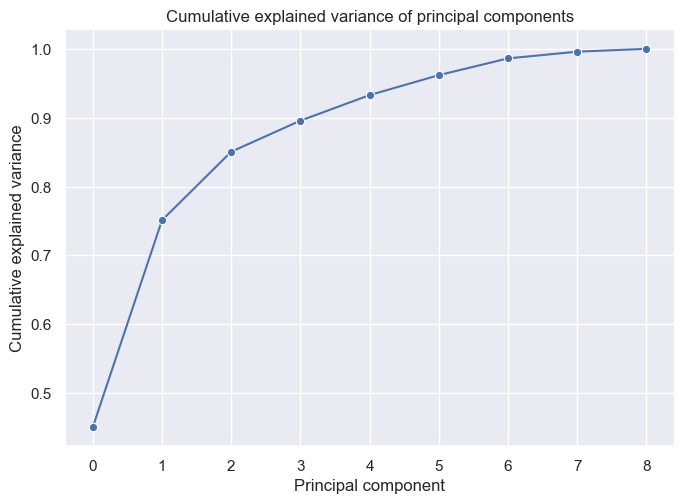

In [191]:
(
  # Create a cumulative explained variance plot
  sns.relplot(
      kind = "line",  # Create a line plot
      x = range(len(explained_variance_array)),  # Set the x-axis to be the principal component index
      y = cumulative_sum_of_variance,  # Set the y-axis to be the cumulative explained variance
      marker = "o",  # Use a circle marker for the data points
      aspect = 1.4,  # Set the aspect ratio of the plot to be 1.4
  )
  # Set the title of the plot
  .set(title = "Cumulative explained variance of principal components")
  # Set the axis labels
  .set_axis_labels("Principal component", "Cumulative explained variance")
);

In [192]:
#PCA – 95% variance method
#Create a PCA object
pca_variance_minmax = PCA(n_components=0.95)

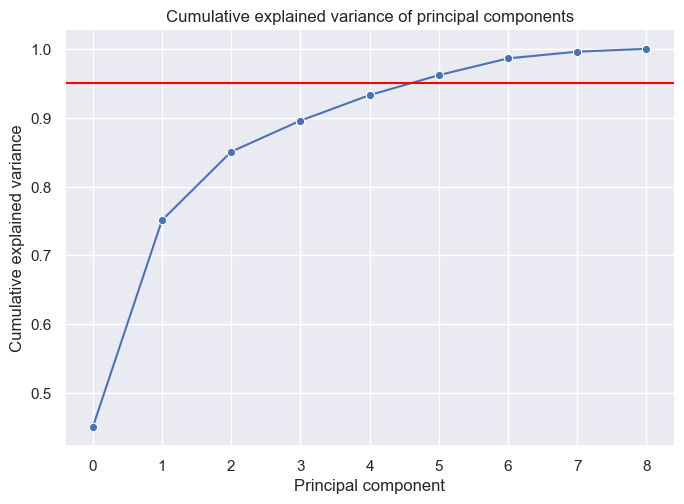

In [193]:
(
  # Create a cumulative explained variance plot
  sns.relplot(
      kind = "line",  # Create a line plot
      x = range(len(explained_variance_array)),  # Set the x-axis to be the principal component index
      y = cumulative_sum_of_variance,  # Set the y-axis to be the cumulative explained variance
      marker = "o",  # Use a circle marker for the data points
      aspect = 1.4,  # Set the aspect ratio of the plot to be 1.4
  )
  # Set the title of the plot
  .set(title="Cumulative explained variance of principal components")
  # Set the axis labels
  .set_axis_labels("Principal component", "Cumulative explained variance")
);

# Add a horizontal red line at 0.95 on the y axis
plt.axhline(y = 0.95,
            color = 'red');

In [194]:
# Fit the PCA object to the scaled features dataframe and transform it
pca_minmax_95_df = pca_variance_minmax.fit_transform(scaled_songs_minmax_df)

# The dataframe now contains the principal components of the scaled features dataframe
pca_minmax_95_df

,pca0,pca1,pca2,pca3,pca4,pca5
song_artist,,,,,,
Se Eu Quiser Falar Com Deus — Gilberto Gil,0.237243,-0.506632,-0.271606,0.526968,0.601342,0.200622
Saudade De Bahia — Antônio Carlos Jobim,-0.210541,-0.386668,0.092842,-0.170832,0.019535,0.098333
"Canta Canta, Minha Gente — Martinho Da Vila",-0.330790,-0.473940,0.285174,-0.004901,0.027263,-0.141709
Mulher Eu Sei — Chico César,0.382249,-0.817310,-0.077702,0.107106,0.215332,0.091806
Rosa Morena — Kurt Elling,0.441013,-0.755697,-0.165229,-0.074260,-0.002093,0.088587
...,...,...,...,...,...,...
"1812 Festival Overture, Op. 49: 1812 Overture, Op. 49 — Pyotr Ilyich Tchaikovsky",1.109831,-0.124585,-0.115768,-0.071955,-0.017395,-0.075191
"Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique — Tristan Murail",0.912219,-0.221587,-0.321282,-0.086268,-0.042533,-0.112657
"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours) — Arnold Schoenberg",1.406071,0.005323,-0.027787,-0.075245,-0.024332,-0.156505


In [195]:
num_components_minmax = pca_variance_minmax.n_components_
print("Components needed for 95% variance (MinMax):", num_components_minmax)

Components needed for 95% variance (MinMax): 6


In [196]:
#Clustering USING Elbow & Silhouette
# Set the maximum number of clusters to try
max_k = 30

# Create an empty list to store the inertia scores
inertia_list = []

# Iterate over the range of cluster numbers
for k in range(1, max_k+1):

    # Create a KMeans object with the specified number of clusters
    myKMeans = KMeans(n_clusters = k,
                      random_state = 42)

    # Fit the KMeans model to the scaled data
    myKMeans.fit(pca_minmax_95_df)

    # Append the inertia score to the list
    inertia_list.append(myKMeans.inertia_)

In [197]:
inertia_list

[2693.358047685921,
 1725.8065672557182,
 1129.2534784943457,
 881.481151835065,
 698.002261878277,
 644.7063460318757,
 586.4056911774654,
 553.8077550490178,
 521.1122117651821,
 498.83598672988785,
 477.58290641096323,
 466.94599302982795,
 452.23169240885295,
 433.4265719155949,
 416.9896708305448,
 410.2857461539262,
 399.6038449509948,
 389.20263635530137,
 382.3760199024296,
 368.3166722130635,
 358.3547473070774,
 351.792397087621,
 347.1220286569755,
 340.38502786756777,
 334.12107474203077,
 329.9874922300449,
 325.2494684874788,
 321.15420373176585,
 316.3948753815124,
 311.6628255917333]

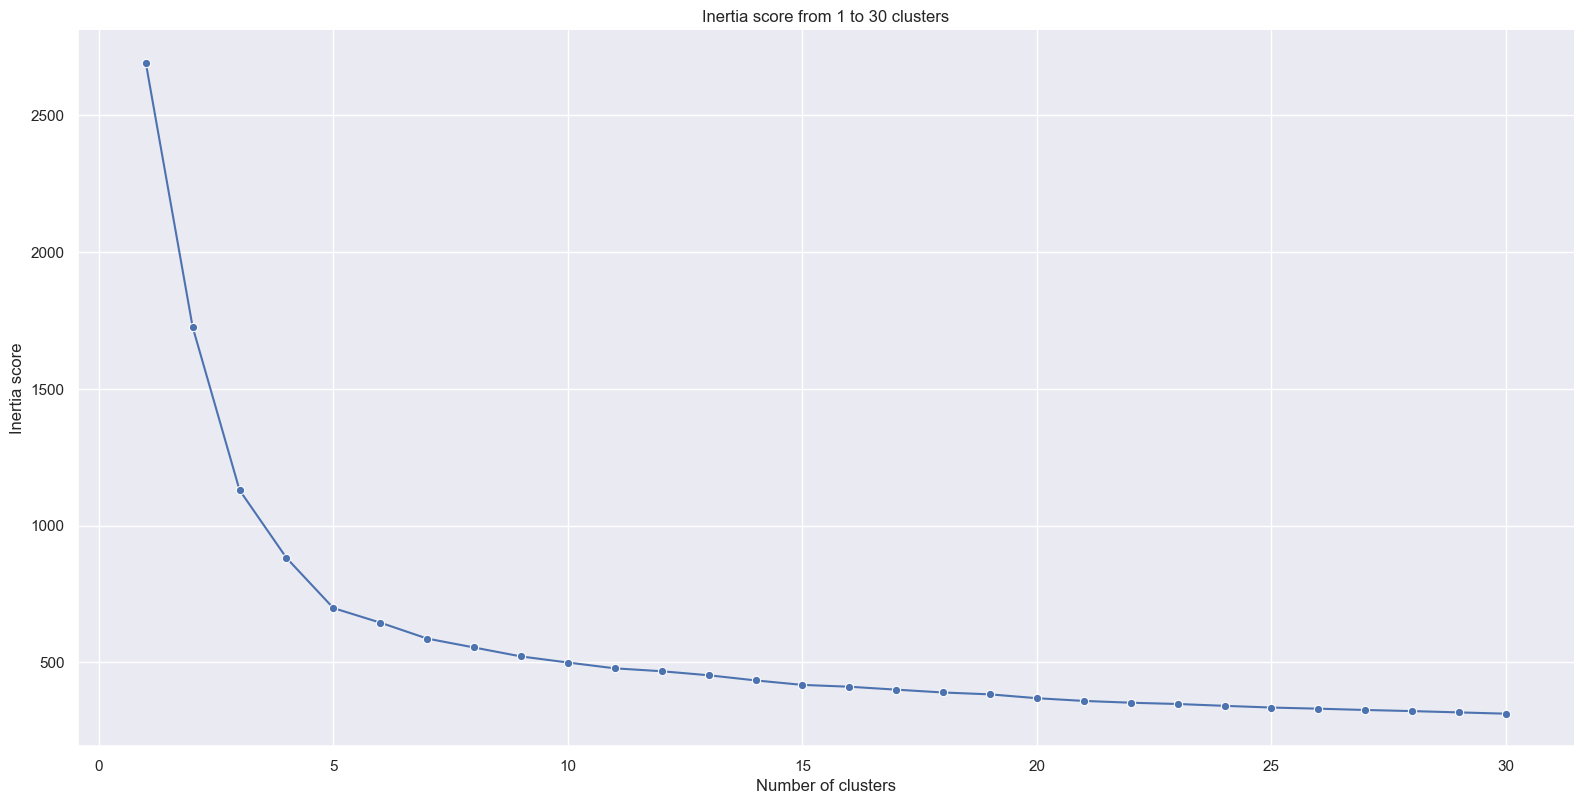

In [198]:
# Set the Seaborn theme to darkgrid
sns.set_theme(style='darkgrid')

(
# Create a line plot of the inertia scores
sns.relplot(y = inertia_list,
            x = range(1, max_k + 1),
            kind = 'line',
            marker = 'o',
            height = 8,
            aspect = 2)
# Set the title of the plot
.set(title=f"Inertia score from 1 to {max_k} clusters")
# Set the axis labels
.set_axis_labels("Number of clusters", "Inertia score")
);

In [199]:
# Set the maximum number of clusters to try
max_k = 30

# Create an empty list to store the silhouette scores
sil_scores = []

for k in range(2, max_k):

    # Create a KMeans object with the specified number of clusters
    kmeans = KMeans(n_clusters = k,
                    random_state = 42)

    # Fit the KMeans model to the scaled data
    kmeans.fit(pca_minmax_95_df)

    # Get the cluster labels
    labels = kmeans.labels_

    # Calculate the silhouette score
    sil_score = silhouette_score(pca_minmax_95_df, labels)

    # Append the silhouette score to the list
    sil_scores.append(sil_score)

In [200]:
sil_scores

[np.float64(0.41400420040252617),
 np.float64(0.3958897815761476),
 np.float64(0.3912934659533693),
 np.float64(0.35554393625127173),
 np.float64(0.2999925393251623),
 np.float64(0.29957667452962505),
 np.float64(0.29512926067017103),
 np.float64(0.3024558257986039),
 np.float64(0.2810872546063746),
 np.float64(0.27323724273445255),
 np.float64(0.2790066630881328),
 np.float64(0.2665338260291102),
 np.float64(0.24190165767403476),
 np.float64(0.2401512365178615),
 np.float64(0.23484328507785293),
 np.float64(0.2230197063253937),
 np.float64(0.22246270298193066),
 np.float64(0.21751405475442184),
 np.float64(0.20392841521659885),
 np.float64(0.1925300027948149),
 np.float64(0.19192382572619318),
 np.float64(0.19278691658937772),
 np.float64(0.1935145951006646),
 np.float64(0.1934222459573266),
 np.float64(0.18668511437923554),
 np.float64(0.18197632465740896),
 np.float64(0.17906753328655511),
 np.float64(0.17878913573155705)]

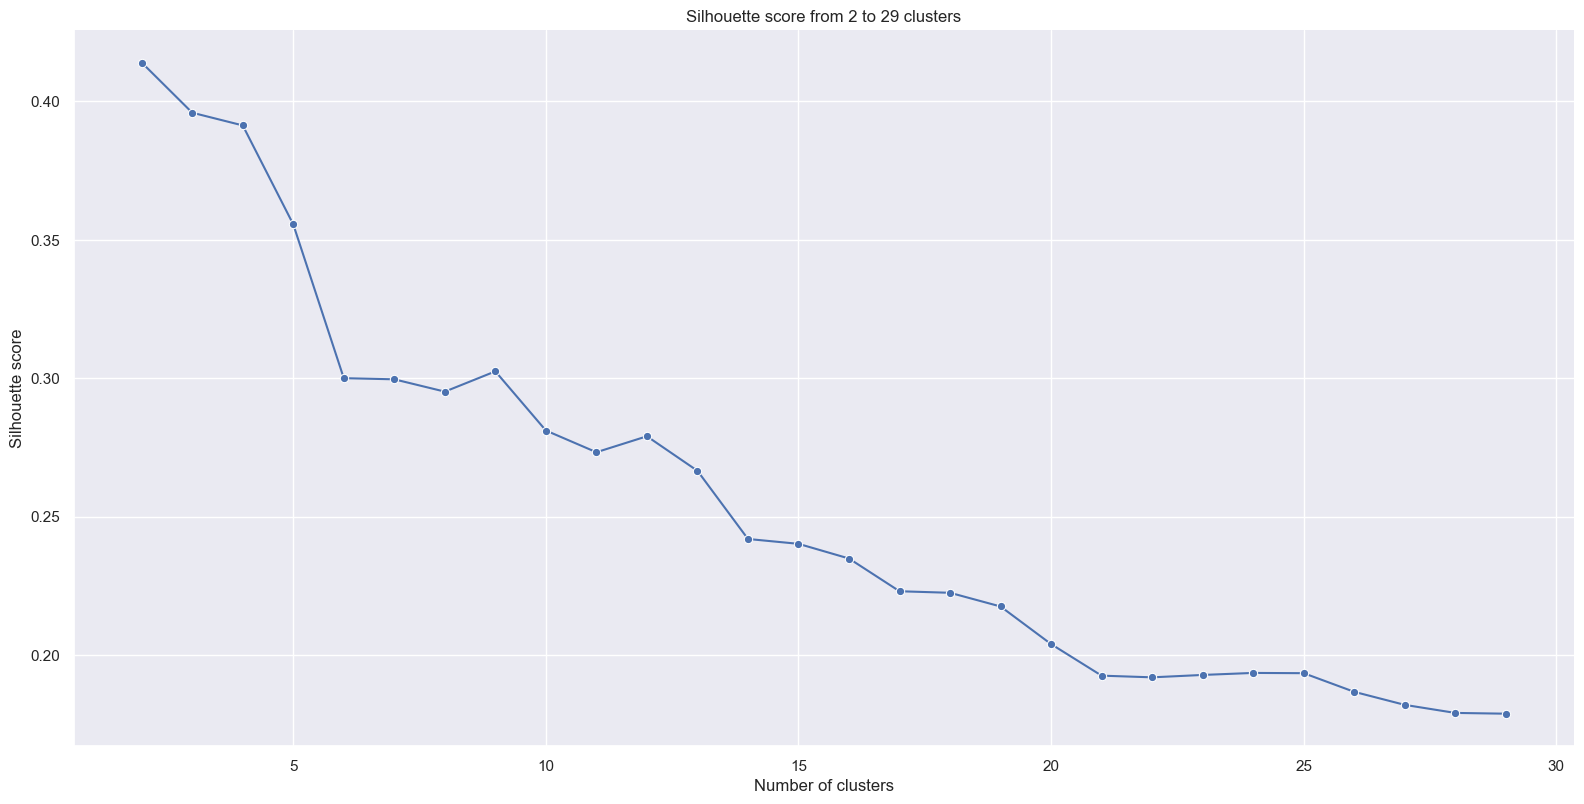

In [201]:
# Plot Silhouette Scores 
(
sns.relplot(y = sil_scores,
            x = range(2, max_k),
            kind = 'line',
            marker = 'o',
            height = 8,
            aspect = 2)
.set(title=f"Silhouette score from 2 to {max_k - 1} clusters")
.set_axis_labels("Number of clusters", "Silhouette score")
);

In [202]:
#By grouping the clusters and looking at the average score for each column

# Initialise the model
my_kmeans = KMeans(n_clusters = 21, # you always choose the number of k here
                   random_state = 42)

# Fit the model to the data
my_kmeans.fit(pca_minmax_95_df)

# Obtain the cluster output
clusters = my_kmeans.labels_

# Attach the cluster output to our original DataFrame
pca_minmax_95_df["cluster"] = clusters

In [203]:
pca_minmax_95_df.groupby(by="cluster").mean()

,pca0,pca1,pca2,pca3,pca4,pca5
cluster,,,,,,
0,1.092240,-0.102374,0.113582,-0.013740,-0.026327,0.144267
1,-0.482556,-0.104625,0.146948,0.063338,-0.133424,0.047951
2,0.129227,0.590701,0.278489,-0.040287,0.046953,0.027594
3,0.302253,-0.625844,-0.087784,0.026500,-0.035810,0.000368
4,-0.231388,0.053757,-0.276488,-0.142093,0.064983,0.099482
5,-0.333734,-0.153538,-0.008850,-0.159636,0.096644,0.029835
6,-0.034822,-0.424462,-0.026782,0.480938,0.238580,0.023930
7,0.065540,-0.298383,-0.192670,-0.019714,-0.030382,0.014928
8,-0.021158,0.530913,-0.099557,0.017917,-0.027306,-0.033693


In [204]:
# Create an empty list to store the Scatterpolar object of each cluster
scatter_objects = []

# State the label for each arm of the chart
categories = pca_minmax_95_df.columns

# Get the means of each feature for each cluster
cluster_feat_means = pca_minmax_95_df.groupby(by="cluster").mean()

# Iterate over the unique clusters and add an object for each cluster to the list
for cluster in sorted(pca_minmax_95_df['cluster'].unique()):

  # Find the mean value for each column of the cluster
  cluster_means = cluster_feat_means.loc[cluster]

  # Create a Scatterpolar object for the cluster
  cluster_scatter = go.Scatterpolar(
    r = cluster_means, # set the radial coordinates
    theta = categories, # the names of the columns
    fill = 'toself', # fills in the space with colour
    name = f'Cluster {cluster}' # adds the name of the cluster
  )

  # Add the Scatterpolar object to the list
  scatter_objects.append(cluster_scatter)

# Create the figure (the white area)
fig = go.Figure()

# Add the scatter objects to the figure
fig.add_traces(scatter_objects)

# Add extras to the plot, such as title
fig.update_layout(
  title_text = 'Radar chart of mean song preferences by cluster',
  height = 600,
  width = 800,
  polar = dict(
    radialaxis = dict(
      visible = True, # visibility of the numbers on the arm
      range = [0, 1] # scale of the plot
    )),
  showlegend = True
)

# Show the initialised plot and the trace objects
fig.show()

In [205]:
# Attach clusters to PCA-transformed data
# Use the KMeans model you already chose (e.g., k=21)
#my_kmeans = KMeans(n_clusters=21, random_state=42)
#clusters = my_kmeans.fit_predict(pca_minmax_95_df)

In [206]:
# Create a DataFrame from PCA components for easier handling
revised_pca_minmax_95_df = pd.DataFrame(pca_minmax_95_df, index=filtered_songlist.index)
revised_pca_minmax_95_df

,pca0,pca1,pca2,pca3,pca4,pca5,cluster
song_artist,,,,,,,
Se Eu Quiser Falar Com Deus — Gilberto Gil,0.237243,-0.506632,-0.271606,0.526968,0.601342,0.200622,6
Saudade De Bahia — Antônio Carlos Jobim,-0.210541,-0.386668,0.092842,-0.170832,0.019535,0.098333,14
"Canta Canta, Minha Gente — Martinho Da Vila",-0.330790,-0.473940,0.285174,-0.004901,0.027263,-0.141709,14
Mulher Eu Sei — Chico César,0.382249,-0.817310,-0.077702,0.107106,0.215332,0.091806,3
Rosa Morena — Kurt Elling,0.441013,-0.755697,-0.165229,-0.074260,-0.002093,0.088587,3
...,...,...,...,...,...,...,...
"1812 Festival Overture, Op. 49: 1812 Overture, Op. 49 — Pyotr Ilyich Tchaikovsky",1.109831,-0.124585,-0.115768,-0.071955,-0.017395,-0.075191,13
"Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique — Tristan Murail",0.912219,-0.221587,-0.321282,-0.086268,-0.042533,-0.112657,19
"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours) — Arnold Schoenberg",1.406071,0.005323,-0.027787,-0.075245,-0.024332,-0.156505,13


In [207]:
# Attach cluster labels
pca_minmax_95_df['cluster'] = clusters
# cluster = array of integers (0–20 for 21 clusters) corresponding to each song in pca_minmax_95_df

In [208]:
# Reattach the original song names to PCA output
pca_minmax_95_df = pd.DataFrame(pca_minmax_95_df, index=song_index)

# Attach clusters back to the original songs
songs_with_clusters = filtered_songlist.merge(
    pd.DataFrame({'cluster': clusters}, index=song_index),
    left_index=True,
    right_index=True
)

songs_with_clusters
# Now songs_with_clusters contains:

# - original numeric features
# - index = song_artist
# - cluster assignment

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,cluster
song_artist,,,,,,,,,,
Se Eu Quiser Falar Com Deus — Gilberto Gil,0.6580,0.25900,-13.141,0.0705,0.694,0.000059,0.9750,0.3060,110.376,6
Saudade De Bahia — Antônio Carlos Jobim,0.7420,0.39900,-12.646,0.0346,0.217,0.000002,0.1070,0.6930,125.039,14
"Canta Canta, Minha Gente — Martinho Da Vila",0.8510,0.73000,-11.048,0.3470,0.453,0.000063,0.1240,0.9050,93.698,14
"Canta Canta, Minha Gente — Martinho Da Vila",0.8510,0.73000,-11.048,0.3470,0.453,0.000063,0.1240,0.9050,93.698,14
Mulher Eu Sei — Chico César,0.7050,0.05020,-18.115,0.0471,0.879,0.000041,0.3860,0.5240,106.802,3
...,...,...,...,...,...,...,...,...,...,...
"1812 Festival Overture, Op. 49: 1812 Overture, Op. 49 — Pyotr Ilyich Tchaikovsky",0.2020,0.06940,-23.390,0.0473,0.917,0.715000,0.0832,0.0655,87.906,13
"Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique — Tristan Murail",0.1880,0.10100,-21.873,0.0442,0.855,0.426000,0.0694,0.0355,83.134,19
"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours) — Arnold Schoenberg",0.0596,0.00093,-42.959,0.0434,0.951,0.969000,0.0772,0.0344,71.573,13


In [209]:
#CLUSTER TABLE SUMMARY
cluster_summary = pca_minmax_95_df.groupby('cluster').mean()
cluster_summary['size'] = pca_minmax_95_df.groupby('cluster').size()
print(cluster_summary)

             pca0      pca1      pca2      pca3      pca4      pca5  size
cluster                                                                  
0        1.092240 -0.102374  0.113582 -0.013740 -0.026327  0.144267   241
1       -0.482556 -0.104625  0.146948  0.063338 -0.133424  0.047951   322
2        0.129227  0.590701  0.278489 -0.040287  0.046953  0.027594   191
3        0.302253 -0.625844 -0.087784  0.026500 -0.035810  0.000368   213
4       -0.231388  0.053757 -0.276488 -0.142093  0.064983  0.099482   295
5       -0.333734 -0.153538 -0.008850 -0.159636  0.096644  0.029835   397
6       -0.034822 -0.424462 -0.026782  0.480938  0.238580  0.023930    60
7        0.065540 -0.298383 -0.192670 -0.019714 -0.030382  0.014928   253
8       -0.021158  0.530913 -0.099557  0.017917 -0.027306 -0.033693   189
9       -0.494182 -0.222207  0.216007 -0.080138  0.033729 -0.044406   422
10      -0.385444  0.051552 -0.082113 -0.007861 -0.030162 -0.002352   410
11      -0.076329  0.285391  0.510728 

In [210]:
# Radar charts per cluster (For radar charts, use the scaled original features rather than PCA components)
categories = filtered_songlist.columns  # original feature names

# compute cluster means on scaled features instead of PCA
scaled_songs_minmax_df['cluster'] = clusters
cluster_feature_means = scaled_songs_minmax_df.groupby('cluster').mean()

for cluster_id in cluster_feature_means.index:
    fig = go.Figure()
    fig.add_trace(go.Scatterpolar(
        r=cluster_feature_means.loc[cluster_id, categories].values,
        theta=categories,
        fill='toself',
        name=f'Cluster {cluster_id}'
    ))
    fig.update_layout(
        polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
        title=f"Cluster {cluster_id} feature profile",
        showlegend=True
    )
    fig.show()


In [211]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

categories = filtered_songlist.columns  
scaled_songs_minmax_df['cluster'] = clusters
cluster_feature_means = scaled_songs_minmax_df.groupby('cluster').mean()

# Decide how many clusters per row
clusters_per_row = 3
num_clusters = len(cluster_feature_means)
num_rows = (num_clusters + clusters_per_row - 1) // clusters_per_row  

# Create subplot figure with polar charts
fig = make_subplots(
    rows=num_rows, cols=clusters_per_row,
    specs=[[{'type':'polar'}]*clusters_per_row]*num_rows,
    subplot_titles=[f"Cluster {c}" for c in cluster_feature_means.index]
)

# Add radar traces to subplots
row = 1
col = 1
for cluster_id in cluster_feature_means.index:
    fig.add_trace(
        go.Scatterpolar(
            r=cluster_feature_means.loc[cluster_id, categories].values,
            theta=categories,
            fill='toself',
            name=f'Cluster {cluster_id}',
            showlegend=False  # optional to hide repeated legend
        ),
        row=row,
        col=col
    )
    col += 1
    if col > clusters_per_row:
        col = 1
        row += 1

# Update layout
fig.update_layout(
    height=300*num_rows,  # adjust height per row
    width=1200,
    title_text="Feature Profiles per Cluster",
)

fig.show()


In [212]:

# playlists per cluster

for c in sorted(songs_with_clusters['cluster'].unique()):
    playlist = songs_with_clusters[songs_with_clusters['cluster'] == c]

    print(f"\n--- Cluster {c}: {len(playlist)} songs ---")

    df_show = playlist[['cluster']].reset_index()
    df_show.rename(columns={'index': 'song_artist'}, inplace=True)

    print(df_show[['song_artist', 'cluster']].head(10))



--- Cluster 0: 243 songs ---
                                         song_artist  cluster
0  Brigas Nunca Mais                             ...        0
1  Aquarela Do Brasil                            ...        0
2  Paranoid Android                              ...        0
3  Zamba del Carnaval                            ...        0
4  Albatross - 2018 Remaster                     ...        0
5  Two Skies                                     ...        0
6  Perfect                                       ...        0
7  Halo                                          ...        0
8  Wishing                                       ...        0
9  III. Andante                                  ...        0

--- Cluster 1: 332 songs ---
                                         song_artist  cluster
0  Lá Vem O Brasil Descendo A Ladeira            ...        1
1  Tirei o Chapéu                                ...        1
2  Baby Lee                                      ...        1
3  Come Sa

In [213]:
# Try a wider range of cluster numbers for business use case
min_k = 10
max_k = 70

inertia_list = []
sil_scores = []
k_values = range(min_k, max_k + 1)

print("Running KMeans for k=10 to 70...")


Running KMeans for k=10 to 70...


In [214]:
for k in k_values:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(pca_minmax_95_df)

    inertia_list.append(model.inertia_)
    sil_scores.append(silhouette_score(pca_minmax_95_df, model.labels_))

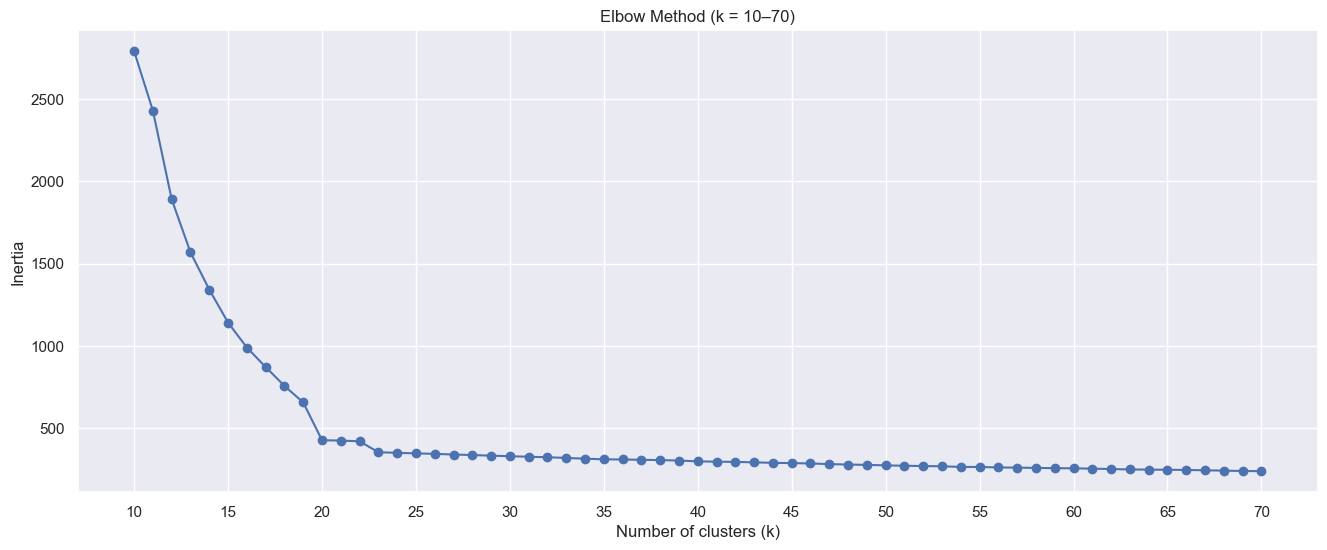

In [215]:
sns.set_theme(style='darkgrid')
plt.figure(figsize=(16, 6))

plt.plot(k_values, inertia_list, marker='o')
plt.title("Elbow Method (k = 10–70)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.xticks(range(10, 71, 5))

# Save the plot (choose any filename and format)
plt.savefig("elbow_curve.png", dpi=300, bbox_inches='tight')

plt.show()


In [216]:
# Save the plot (choose any filename and format)
plt.savefig("elbow_curve.png", dpi=300, bbox_inches='tight')

plt.show()

<Figure size 640x480 with 0 Axes>

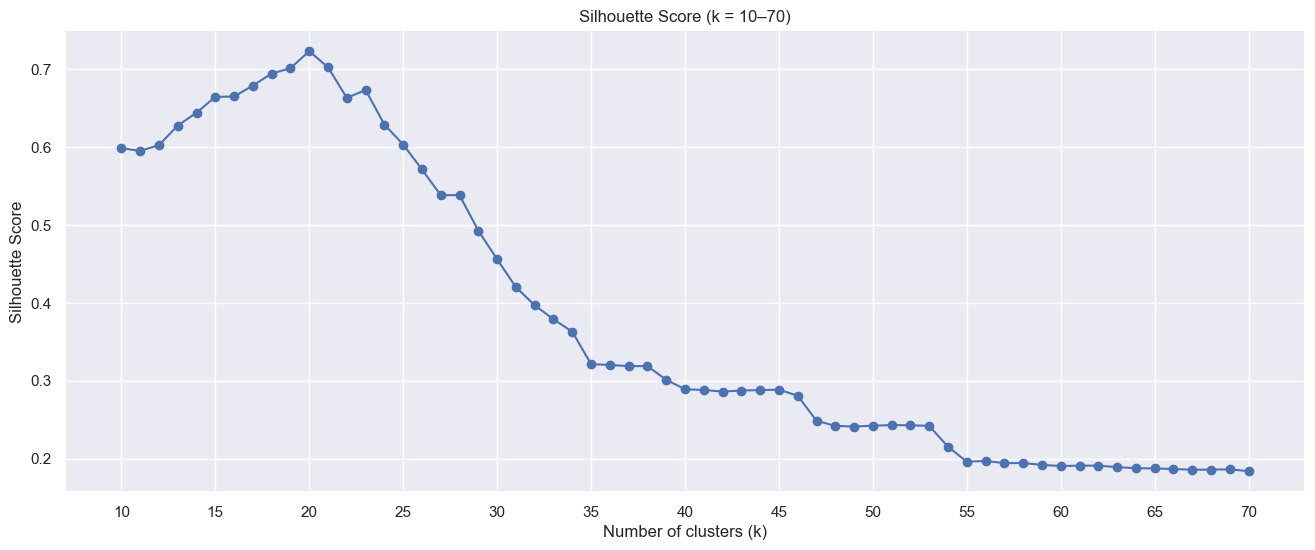

In [217]:
#Plot Silhouette Scores
plt.figure(figsize=(16, 6))
plt.plot(k_values, sil_scores, marker='o')
plt.title("Silhouette Score (k = 10–70)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(range(10, 71, 5))
plt.show()

In [218]:
# Save as PNG
plt.savefig("silhouette_score.png", dpi=300, bbox_inches='tight')

plt.show()

<Figure size 640x480 with 0 Axes>

In [219]:
#Recommend Best K
# Convert to array for indexing
sil_array = np.array(sil_scores)

# Find k with highest silhouette
best_k_silhouette = k_values[np.argmax(sil_array)]

print(f"🔍 Best k based on silhouette score: {best_k_silhouette}")
print(f"Silhouette score = {sil_array.max():.4f}")

🔍 Best k based on silhouette score: 20
Silhouette score = 0.7232


In [220]:
#Business Rule Filtering (playlist size)
usable_k = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42).fit(pca_minmax_95_df)
    labels = model.labels_

    cluster_counts = pd.Series(labels).value_counts()

    if cluster_counts.min() >= 30 and cluster_counts.max() <= 500:
        usable_k.append(k)

print("K values that produce usable playlist sizes (30–500 songs):")
print(usable_k)


K values that produce usable playlist sizes (30–500 songs):
[20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37]


In [221]:
#check if the songs in clusters are unique
songs_with_clusters.index.is_unique


False